




ANÁLISIS EXPLORATORIO

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('diabetes_dataset.csv')
display(df.head())

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [ ]:
df.shape

(100000, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [ ]:
print("Valores nulos por columna:\n", df.isna().sum().sort_values(ascending=False).head(30))
print("DUPLICADOS", df.duplicated().sum())

Valores nulos por columna:
 age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fast

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


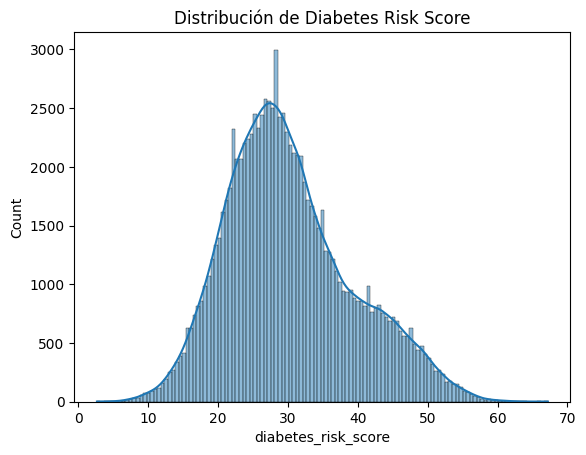

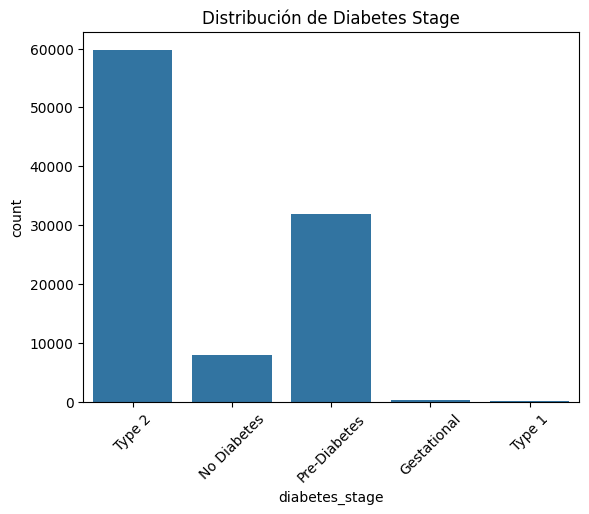

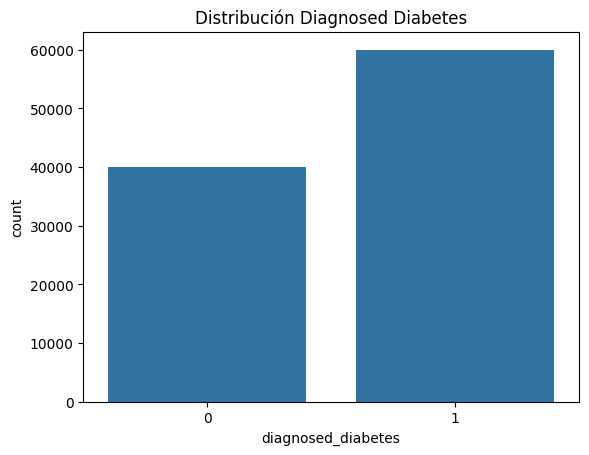

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma del risk score
plt.figure()
sns.histplot(df["diabetes_risk_score"], kde=True)
plt.title("Distribución de Diabetes Risk Score")
plt.show()

# Conteo de clases - diabetes_stage
plt.figure()
sns.countplot(x=df["diabetes_stage"])
plt.title("Distribución de Diabetes Stage")
plt.xticks(rotation=45)
plt.show()

# Conteo binario
plt.figure()
sns.countplot(x=df["diagnosed_diabetes"])
plt.title("Distribución Diagnosed Diabetes")
plt.show()

Correlación de las variables numéricas con 'diabetes_risk_score':


,diabetes_risk_score
diabetes_risk_score,1.000000
family_history_diabetes,0.733085
age,0.495924
glucose_fasting,0.469938
hba1c,0.329947
systolic_bp,0.323591
bmi,0.313813
diagnosed_diabetes,0.277300
glucose_postprandial,0.277041
waist_to_hip_ratio,0.241651


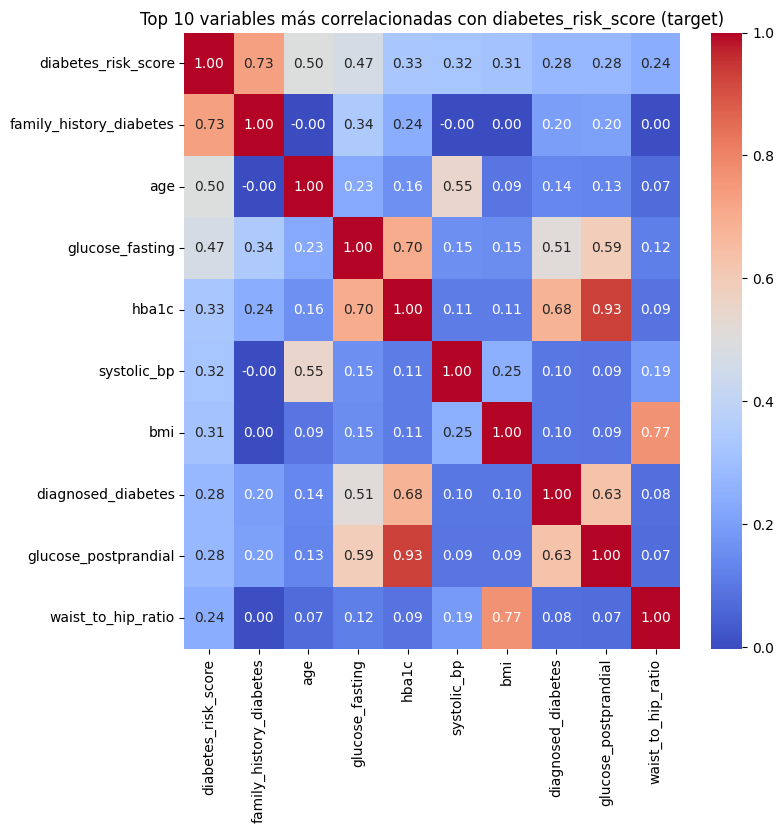

In [ ]:
# Calcular la matriz de correlación solo para variables numéricas
correlaciones = df.corr(numeric_only=True)

# Aislar las correlaciones respecto a nuestra variable objetivo (risk score)
corr_con_objetivo = correlaciones['diabetes_risk_score'].sort_values(ascending=False)

# Mostrar en una tabla
print("Correlación de las variables numéricas con 'diabetes_risk_score':")
display(pd.DataFrame(corr_con_objetivo))

# Graficar un mapa de calor con las 10 variables más fuertemente correlacionadas
top_10_vars = corr_con_objetivo.head(10).index
plt.figure(figsize=(8, 8))
sns.heatmap(df[top_10_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 variables más correlacionadas con diabetes_risk_score (target)')
plt.show()

PREPROCESAMIENTO

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Hacemos copia del dataset y aplicamos OneHot encoding
columnas_categoricas = ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']
df_procesado = pd.get_dummies(df.copy(), columns=columnas_categoricas, drop_first=True)

# 2. DEFINIMOS LAS VARIABLES (X e y)
X = df_procesado.drop(columns=['diabetes_risk_score', 'diabetes_stage', 'diagnosed_diabetes'])
y_clf = df_procesado['diabetes_stage']       # Para clasificación
y_reg = df_procesado['diabetes_risk_score']  # Para regresión

# 3. PRIMERO DIVIDIMOS (Train/Test Split)
# Dividimos basándonos en clasificación para poder usar "stratify"
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Emparejamos las etiquetas de regresión usando los mismos índices para que todo coincida
y_train_reg = y_reg.loc[X_train.index]
y_test_reg = y_reg.loc[X_test.index]

# 4. LUEGO ESCALAMOS (Solo ajustamos en Train)
columnas_numericas = ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
                      'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day',
                      'family_history_diabetes', 'hypertension_history', 'cardiovascular_history',
                      'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
                      'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
                      'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']

scaler = StandardScaler()

# FIT_TRANSFORM en el set de Entrenamiento
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])

# SOLO TRANSFORM en el set de Prueba
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

print("División y escalado listos.")
print(f"X_train tiene {X_train.shape[0]} filas.")
print(f"X_test tiene {X_test.shape[0]} filas.")

División y escalado listos.
X_train tiene 80000 filas.
X_test tiene 20000 filas.


MODELO DE REGRESIÓN

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Creamos el modelo
modelo_lineal = LinearRegression()

# 2. Entrenamos al modelo pasándole los datos de estudio y las respuestas correctas
# (Usamos las variables "reg" que creamos específicamente para el puntaje de riesgo)
modelo_lineal.fit(X_train, y_train_reg)

# 3. Predecimos el riesgo de los pacientes de prueba
y_pred_lineal = modelo_lineal.predict(X_test)

# 4. Comparamos sus respuestas (y_pred_lineal) con la realidad (y_test_reg)
mae_lineal = mean_absolute_error(y_test_reg, y_pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test_reg, y_pred_lineal))
r2_lineal = r2_score(y_test_reg, y_pred_lineal)

print("--- RESULTADOS: REGRESIÓN LINEAL ---")
print(f"MAE (Error Absoluto Medio): {mae_lineal:.2f} puntos")
print(f"RMSE (Error Cuadrático Medio): {rmse_lineal:.2f} puntos")
print(f"R² (Coeficiente de Determinación): {r2_lineal:.4f}")

--- RESULTADOS: REGRESIÓN LINEAL ---
MAE (Error Absoluto Medio): 0.44 puntos
RMSE (Error Cuadrático Medio): 0.77 puntos
R² (Coeficiente de Determinación): 0.9927


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Creamos el modelo
# n_estimators=100 significa que creará 100 árboles de decisión,
# random_state=42 es para que los resultados sean los mismos si lo vuelves a correr
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenamos al modelo
print("Entrenando Random Forest... por favor espera.")
modelo_rf.fit(X_train, y_train_reg)

# 3. Predecimos
y_pred_rf = modelo_rf.predict(X_test)

# 4. Calculamos sus métricas
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
r2_rf = r2_score(y_test_reg, y_pred_rf)

print("\n--- RESULTADOS: RANDOM FOREST ---")
print(f"MAE: {mae_rf:.2f} puntos")
print(f"RMSE: {rmse_rf:.2f} puntos")
print(f"R²: {r2_rf:.4f}")

Entrenando Random Forest... por favor espera.

--- RESULTADOS: RANDOM FOREST ---
MAE: 0.63 puntos
RMSE: 0.83 puntos
R²: 0.9916


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Creamos el modelo XGBoost
modelo_xgb = xgb.XGBRegressor(n_estimators=100, random_state=42)

# 2. Entrenamos el modelo
print("Entrenando XGBoost... por favor espera.")
modelo_xgb.fit(X_train, y_train_reg)

# 3. Predecimos
y_pred_xgb = modelo_xgb.predict(X_test)

# 4. Calculamos sus métricas
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
r2_xgb = r2_score(y_test_reg, y_pred_xgb)

print("\n--- RESULTADOS: XGBOOST ---")
print(f"MAE: {mae_xgb:.2f} puntos")
print(f"RMSE: {rmse_xgb:.2f} puntos")
print(f"R²: {r2_xgb:.4f}")

Entrenando XGBoost... por favor espera.

--- RESULTADOS: XGBOOST ---
MAE: 0.39 puntos
RMSE: 0.50 puntos
R²: 0.9970


MODELO DE CLASIFICACIÓN